<a href="https://colab.research.google.com/github/Seba-Nicola/Proyecto-Data-Science/blob/main/ProyectoParteIII_Nicola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Data Science I

##Abstract

El proyecto se enfoca en el análisis de un conjunto de datos sobre hospitalizaciones relacionadas con diabetes. El Dataset recopila datos de atención clínica en 130 hospitales de Estados Unidos. Cada registro representa el ingreso hospitalario de un paciente con diagnóstico de diabetes cuya estancia duró entre uno y catorce días, reúne mas de 100.000 registos y 25 variables, entre ellas información demográfica, administrativa y clínica.

El objetivo principal es identificar patrones y factores de riesgo asociados con la readmisión hospitalaria temprana (≤ 30 días), un indicador clave para evaluar la calidad asistencial y optimizar la gestión de recursos sanitarios.

El dataset contiene variables categóricas (como raza, género, grupo etario, especialidad médica de atención, fuente de admisión y diagnósticos) y variables numéricas (como días de internación, cantidad de procedimientos, número de medicamentos y procedimientos de laboratorio). El dataset no presentar valores faltantes, facilita un flujo de trabajo enfocado en el análisis exploratorio y el desarrollo de modelos predictivos, evitando las complejidades propias de la imputación.

Las preguntas incluyen:

¿Se observan diferencias en la tasa de readmisión por género, raza o fuente de admisión?

¿Cuáles son las distribuciones típicas de los días de internación y de los medicamentos administrados? ¿Cómo se relacionan a la tasa de readmisión?

¿Existen relaciones entre la complejidad clínica (número de diagnósticos) y la probabilidad de readmisión?

Para abordarlas, se aplicarán visualizaciones univariadas, bivariadas y multivariadas, así como resúmenes estadísticos. El análisis visual permitirá detectar patrones, identificar posibles outliers y explorar asociaciones iniciales entre variables. Las representaciones gráficas se complementarán con medidas descriptivas (mediana, media, rango intercuartílico, proporciones) que ofrezcan contexto numérico a las tendencias observadas.

En la segunda etapa se busca generar modelos predictivos que logren identificar posibles casos de readmisión de pacientes dentro de un período de 30 días a la atención, para esto se evaluan y comparan dos modelos seleccionando el mejor.

En conclusión, el proyecto aborta el punta a punta de la problematica desde el análisis descriptivo, modelado, selección y análisis final.

##Importación de Librerías

In [96]:
#Importación librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

##Carga de Datos

In [97]:
#Lectura del Dataset
url='https://raw.githubusercontent.com/Seba-Nicola/Proyecto-Data-Science/main/diabetes_hospital.xlsx'
df= pd.read_excel(url)
df.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,'30 years or younger',Other,Referral,1,Other,41,0,1,...,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,'30 years or younger','Discharged to Home',Emergency,3,Missing,59,0,18,...,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,'30 years or younger','Discharged to Home',Emergency,2,Missing,11,5,13,...,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,2,Missing,44,1,16,...,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,1,Missing,51,0,8,...,Ch,Yes,False,False,False,False,False,NO,0,0


##Análisis Exploratorio (EDA)

In [98]:
#Información de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   discharge_disposition_id  101766 non-null  object
 4   admission_source_id       101766 non-null  object
 5   time_in_hospital          101766 non-null  int64 
 6   medical_specialty         101766 non-null  object
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  primary_diagnosis         101766 non-null  object
 11  number_diagnoses          101766 non-null  int64 
 12  max_glu_serum             5346 non-null    object
 13  A1Cresult                 17018 non-null   object
 14  insu

**rece:** grupo étnico del paciente (ej: Caucasian, AfricanAmerican, Asian, etc.).

**gender:** sexo del paciente (ej: Female, Male, Unknown/Invalid).

**age:** grupo etario del paciente (ej: '30 years or younger', '30-60 years', 'Over 60 years').

**discharge_disposition:** Destino del paciente al momento de alta (ej: Discharged to Home, Other).

**admission_source_id:** Fuente de admisión hospitalaria (ej: Referral, Emergency, Other).

**time_in_hospital:** duración de la hospitalización (días).

**medical_speciality:** especialidad del profesional que atendió al paciente.

**num_lab_procedures**: número de laboratorios realizados en la estadia.

**num_procedures:** número de procedimientos médicos.

**num_medications:** cantidad de medicamentos administrados.

**primary_diagnosis:** diagnóstico principal del paciente según codificación.

**max_glu_serum:** valor máximo de glucosa en suero durante la estancia (categorizado).

**A1Cresult:** resultado de la prueba A1C (hemoglobina glicosilada), categorizado.

**insulin**: estatus del tratamiento con insulina durante la estancia (ej: No, Steady, Up, Down).

**change:** indica si hubo un cambio de medicación durante la estancia.

**diabetesMed** indica si el paciente recibió medicación para la diabétes.

**had_inpatient_days:** indica si el paciente tuvo días de hospitalización.

**had_outpatient_days:** indica si el paciente tuvo días de atención ambulatoria previos.

**readmitted:**Estado de readmisión del paciente (NO, >30, ).

**readmit_binary:** variable binaria de readmición.

**readmit_30_days:** indica si la persona fue readmitida dentro de los 30 días.




In [99]:
#Tamaño del dataset
df.shape

(101766, 25)

In [100]:
#Descripción de variables numéricas
df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_binary,readmit_30_days
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,7.422607,0.460881,0.111599
std,2.985108,19.674362,1.705807,8.127566,1.933600,0.498470,0.314874
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,31.000000,0.000000,10.000000,6.000000,0.000000,0.000000
50%,4.000000,44.000000,1.000000,15.000000,8.000000,0.000000,0.000000
75%,6.000000,57.000000,2.000000,20.000000,9.000000,1.000000,0.000000
max,14.000000,132.000000,6.000000,81.000000,16.000000,1.000000,1.000000


In [101]:
# Valores con 0
columnas = df.columns[0:]
nun_missing = (df[columnas] == 0).sum()
print(nun_missing)

race                            0
gender                          0
age                             0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
medical_specialty               0
num_lab_procedures              0
num_procedures              46652
num_medications                 0
primary_diagnosis               0
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
insulin                         0
change                          0
diabetesMed                     0
medicare                    69327
medicaid                    98234
had_emergency               90383
had_inpatient_days          67630
had_outpatient_days         85027
readmitted                      0
readmit_binary              54864
readmit_30_days             90409
dtype: int64


In [102]:
# Valores nulos
nulos_total = df.isnull().sum().sum()
nulos_por_col = df.isnull().sum().sort_values(ascending=False)
display(nulos_por_col.head(20))
print("Nulos totales:", int(nulos_total))

,0
max_glu_serum,96420
A1Cresult,84748
age,0
gender,0
admission_source_id,0
time_in_hospital,0
medical_specialty,0
discharge_disposition_id,0
race,0
num_procedures,0


Nulos totales: 181168


###Visualizaciones

####Tasa de Readmisión por Género

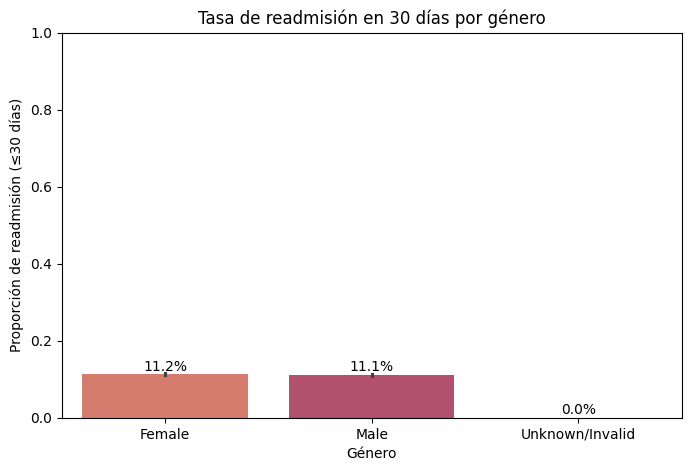

In [103]:
#Tasa de readmisión por género
plt.figure(figsize=(8,5))
sns.barplot(
    x="gender",
    y="readmit_30_days",
    data=df,
    estimator=lambda x: sum(x)/len(x),
    hue="gender",
    palette="flare"
)
plt.ylabel("Proporción de readmisión (≤30 días)")
plt.xlabel("Género")
plt.title("Tasa de readmisión en 30 días por género")
plt.ylim(0,1)

# Etiquetas de porcentaje
tasa_genero = df.groupby("gender")["readmit_30_days"].mean()
for i, (cat, val) in enumerate(tasa_genero.items()):
    plt.text(i, val+0.01, f"{val:.1%}", ha='center')

plt.show()

- La **proporción de readmisión (≤30 días)** es similar entre *Female* y *Male*.  
- Diferencias pequeñas sugieren que el **género** no es un determinante fuerte en este dataset.

####Tasa de Readmisión por Raza



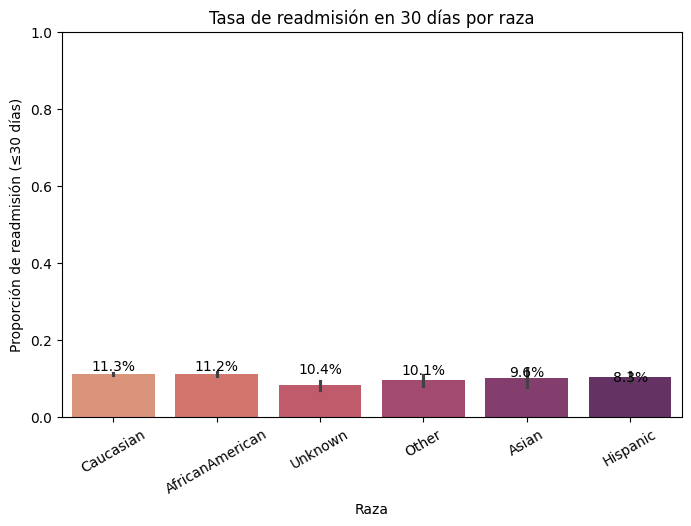

In [104]:
#Tasa de readmisión por raza
plt.figure(figsize=(8,5))
sns.barplot(
    x="race",
    y="readmit_30_days",
    data=df,
    estimator=lambda x: sum(x)/len(x),
    hue="race",
    palette="flare"
)
plt.ylabel("Proporción de readmisión (≤30 días)")
plt.xlabel("Raza")
plt.title("Tasa de readmisión en 30 días por raza")
plt.ylim(0,1)
plt.xticks(rotation=30)

# Etiquetas
tasa_race = df.groupby("race")["readmit_30_days"].mean().sort_values(ascending=False)
for i, (cat, val) in enumerate(tasa_race.items()):
    plt.text(i, val+0.01, f"{val:.1%}", ha='center')

plt.show()

**Interpretación – Tasa de readmisión por raza**  
- Las **tasas** entre grupos raciales son cercanas (brecha de pocos puntos porcentuales).  
- *Unknown* refleja **falta de registro** más que un patrón clínico.

####Tasa de Readmisión por Fuente de Admisión

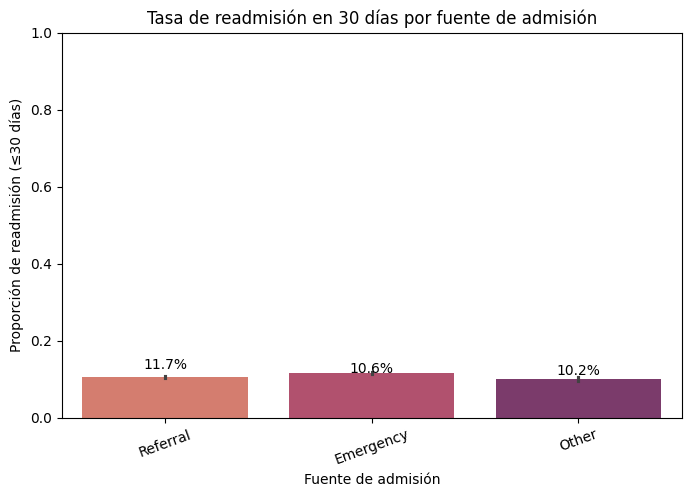

In [105]:
#Tasa de readmisión por fuente de admisión
plt.figure(figsize=(8,5))
sns.barplot(
    x="admission_source_id",
    y="readmit_30_days",
    data=df,
    estimator=lambda x: sum(x)/len(x),
    hue="admission_source_id",
    palette="flare"
)
plt.ylabel("Proporción de readmisión (≤30 días)")
plt.xlabel("Fuente de admisión")
plt.title("Tasa de readmisión en 30 días por fuente de admisión")
plt.ylim(0,1)
plt.xticks(rotation=20)

# Etiquetas
tasa_admission = df.groupby("admission_source_id")["readmit_30_days"].mean().sort_values(ascending=False)
for i, (cat, val) in enumerate(tasa_admission.items()):
    plt.text(i, val+0.01, f"{val:.1%}", ha='center')

plt.show()

**Interpretación – Tasa de readmisión por fuente de admisión**  
- La vía **Emergency** tiende a mayor readmisión (casos más agudos).  
- **Referral** y **Other** suelen ser más bajos.  
- La **vía de ingreso** puede ser útil para segmentar riesgo.

####Variables Numéricas

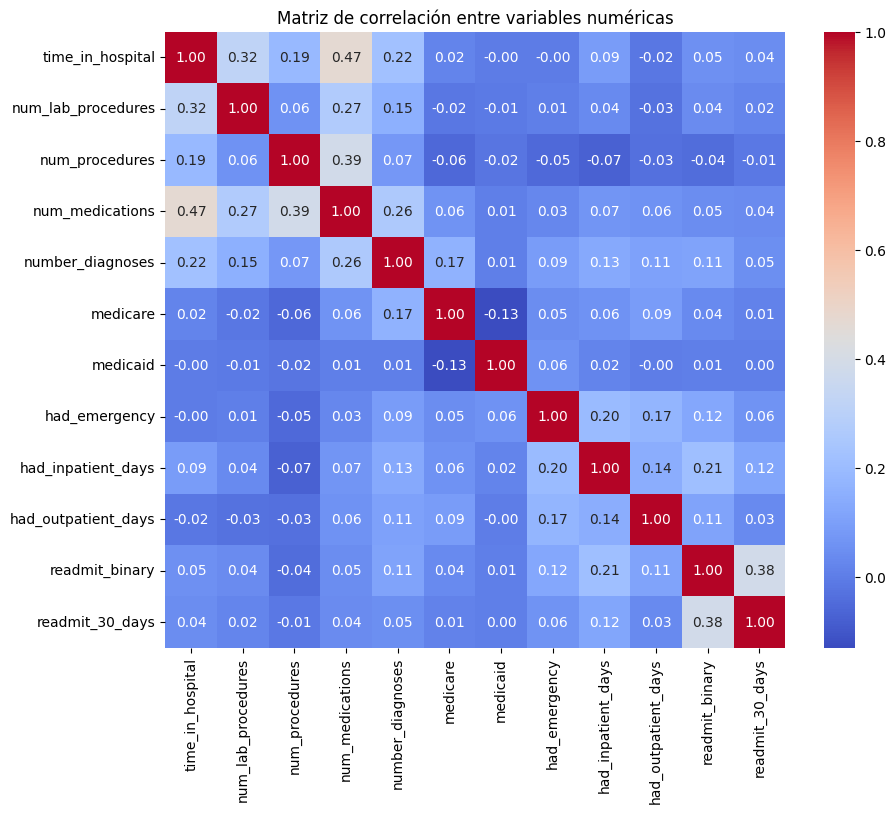

In [106]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

**Interpretación** – `num_medications` tiene un mayor índice de correlación con `time_in_hospital`, `num_procedures`,`num_lab_procedures` y `num_diagnosis`

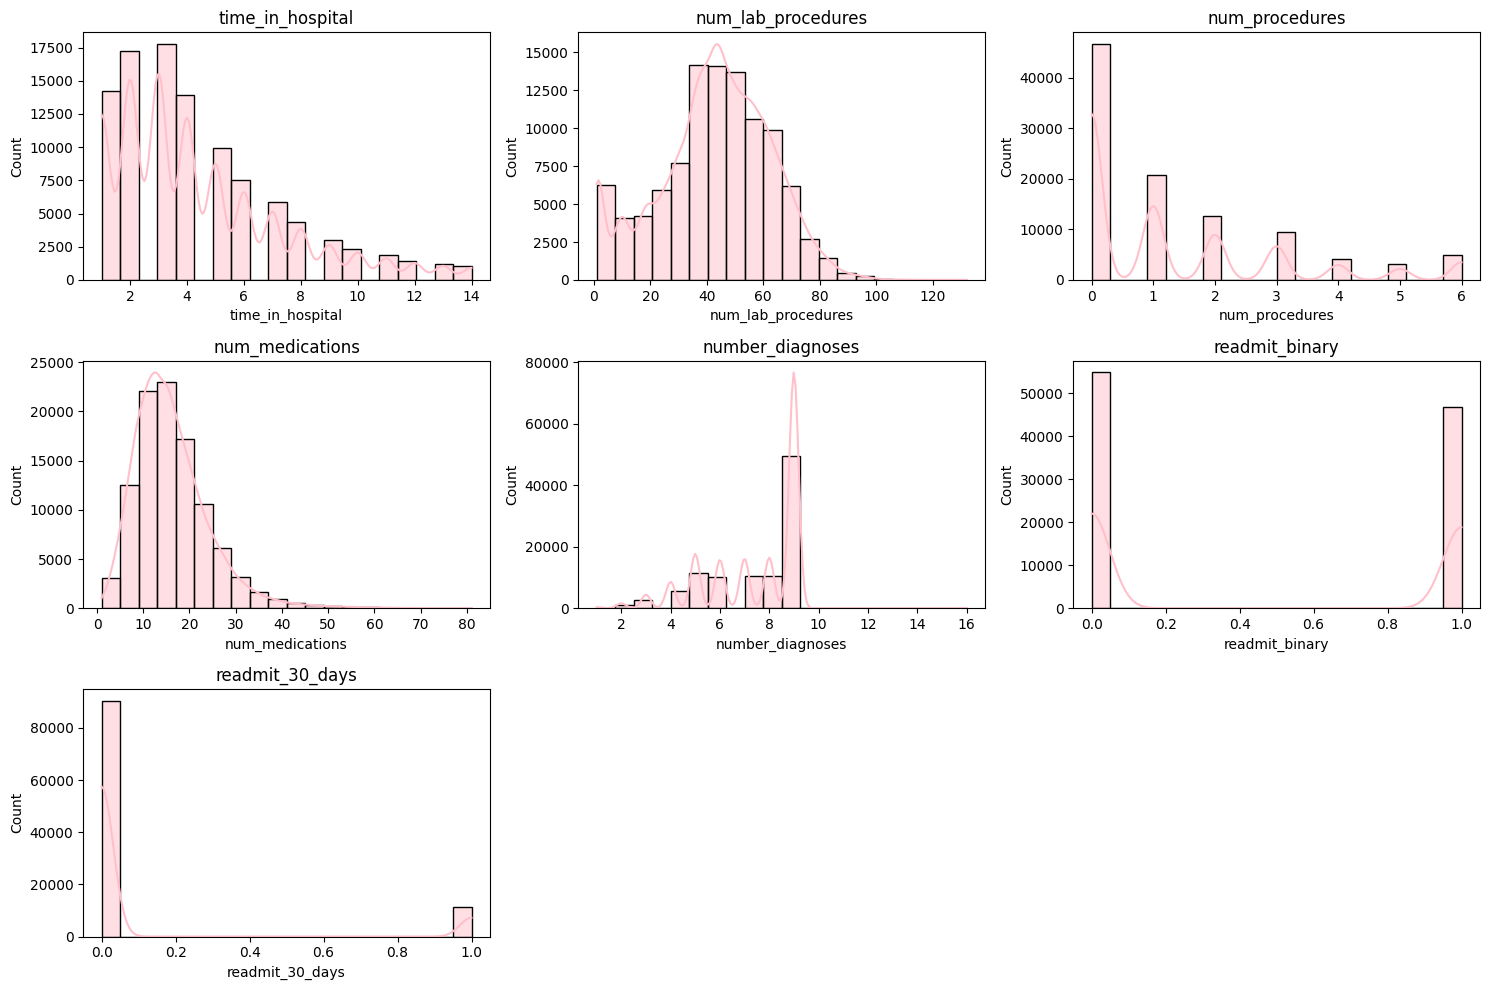

In [107]:
# Variables numéricas
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color="pink")
    plt.title(col)
plt.tight_layout()
plt.show()

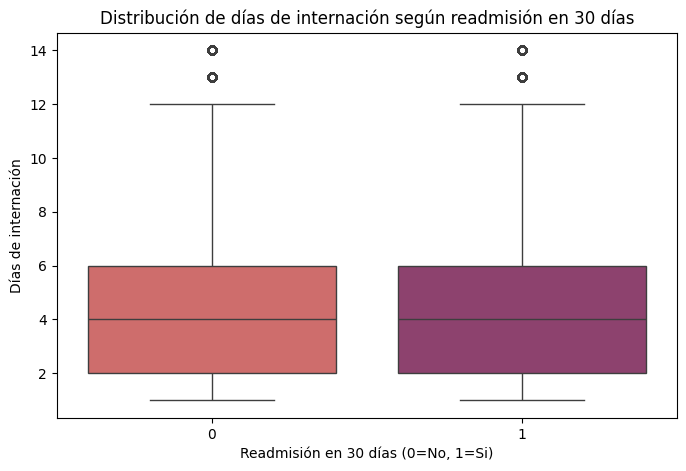

In [108]:
# Distribución de días de admisión según readmisión en 30 días
plt.figure(figsize=(8,5))
sns.boxplot(
    x="readmit_30_days",
    y="time_in_hospital",
    data=df,
    hue="readmit_30_days",
    legend=False,
    palette="flare"
)
plt.xlabel("Readmisión en 30 días (0=No, 1=Si)")
plt.ylabel("Días de internación")
plt.title("Distribución de días de internación según readmisión en 30 días")
plt.show()

**Interpretación – `time_in_hospital` según readmisión**  
-No se observan grandes diferencias según la visualización de esta variable.

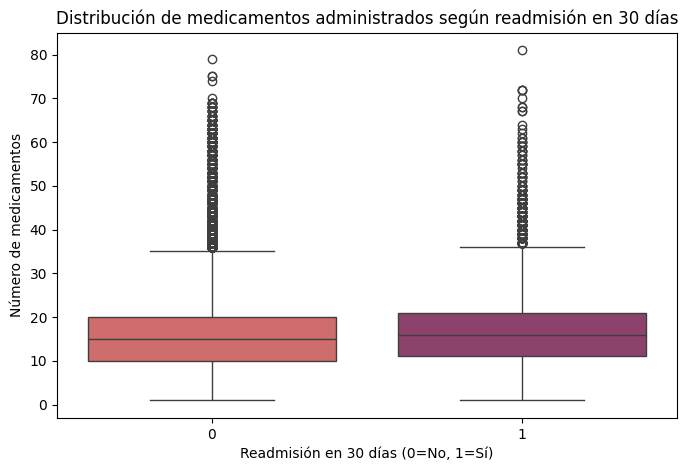

In [109]:
# Distribución de medicamentos administrados según readmisión en 30 días
plt.figure(figsize=(8,5))
sns.boxplot(
    x="readmit_30_days",
    y="num_medications",
    data=df,
    hue="readmit_30_days",
    legend=False,
    palette="flare",
    )
plt.xlabel("Readmisión en 30 días (0=No, 1=Sí)")
plt.ylabel("Número de medicamentos")
plt.title("Distribución de medicamentos administrados según readmisión en 30 días")
plt.show()

**Interpretación – `num_medications` según readmisión**  
- Una **mediana** más alta en readmitidos sugiere que la cantidad de medicamentos suministrados puede ser un factor influyente.  
- Puede haber efecto por **outliers**.

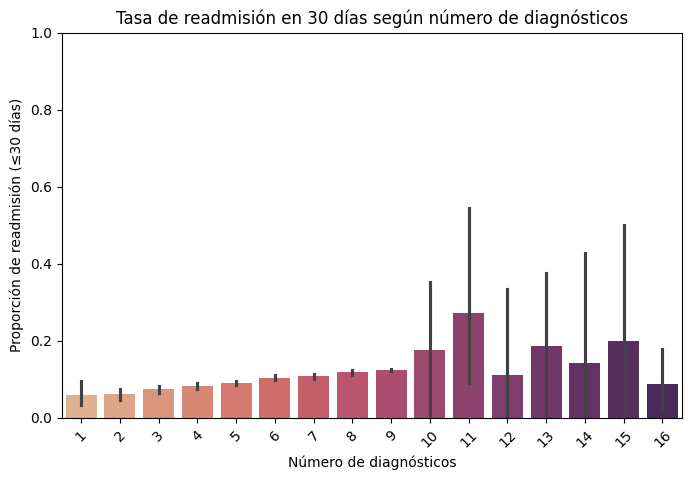

In [110]:
# Tasa de readmisión en 30 días según número de diagnósticos
plt.figure(figsize=(8,5))
sns.barplot(
    x="number_diagnoses",
    y="readmit_30_days",
    data=df,
    estimator=lambda x: sum(x)/len(x),
    hue="number_diagnoses",
    legend=False,
    palette="flare",
)
plt.xlabel("Número de diagnósticos")
plt.ylabel("Proporción de readmisión (≤30 días)")
plt.title("Tasa de readmisión en 30 días según número de diagnósticos")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()

**Interpretación – `num_diagnosis` según readmisión**  
- Tendencia de la tasa creciente a mayor número de diagnosticos.

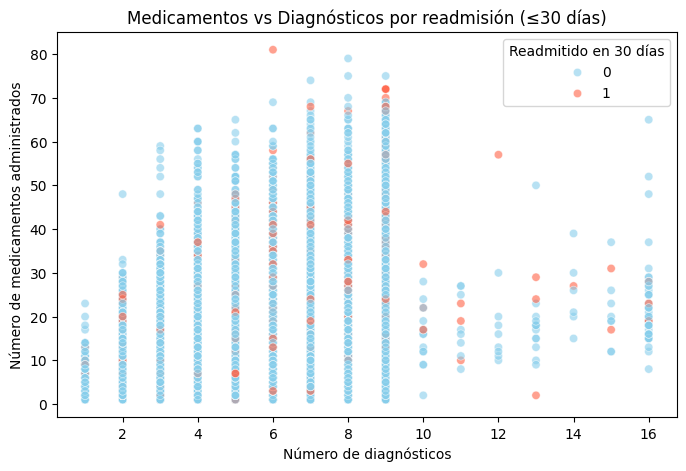

In [111]:
# Reingresos en 30 días en función de número de medicamentos administrados y número de diagnósticos
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="number_diagnoses",
    y="num_medications",
    hue="readmit_30_days",
    hue_order=[0,1],
    alpha=0.6,
    palette={0: "skyblue", 1: "tomato"}
)
plt.xlabel("Número de diagnósticos")
plt.ylabel("Número de medicamentos administrados")
plt.title("Medicamentos vs Diagnósticos por readmisión (≤30 días)")
plt.legend(title="Readmitido en 30 días")
plt.show()

**Interpretación**
Se estudiaron las relaciones de dos variables identificadas como influyentes en la tasa de readmisión, – `num_medications` y `num_diagnosis`. No se observa un patrón claro en el gráfico.

## Feature Engineering (Ingeniería de Características)

In [112]:
# Variable objetivo
df_fe = df.copy()
target_col = "readmit_30_days"
y = df_fe[target_col].astype(int)

# Features (sin la variable target, y variables con cierto vínculo con la target)
X_fe = df_fe.drop(columns=[target_col,'readmitted','readmit_binary'])

# Identificar variables numéricas y categóricas
num_cols = X_fe.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_fe.select_dtypes(include=["object", "category"]).columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print("Cantidad de variables categóricas:", len(cat_cols))
print("Numéricas:", num_cols[:])
print("Categóricas:", cat_cols[:])

Cantidad de variables numéricas: 10
Cantidad de variables categóricas: 12
Numéricas: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'medicare', 'medicaid', 'had_emergency', 'had_inpatient_days', 'had_outpatient_days']
Categóricas: ['race', 'gender', 'age', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'primary_diagnosis', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed']


In [113]:
# Características a usar (excluyendo 'target')
features = num_cols + cat_cols
target = 'target_col'

## Preprocesamiento de Datos

In [114]:
# Definir las características (X) y la variable objetivo (y)
X = df_fe[features]
y = df_fe[target_col]

In [115]:
# Crear el preprocesador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


In [116]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['time_in_hospital', 'num_lab_procedures',
                                  'num_procedures', 'num_medications',
                                  'number_diagnoses', 'medicare', 'medicaid',
                                  'had_emergency', 'had_inpatient_days',
                                  'had_outpatient_days']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['race', 'gender', 'age',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'medical_specialty',
                                  'primary_diagnosis', 'max_glu_serum',
                                  'A1Cresult', 'insulin', 'change',
                                  'diabetesMed'])])

##División de Datos

In [117]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

##Modelado y Evaluación

###Random Forest

In [118]:
# Pipeline
RF_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

In [119]:
# Entrenar el pipeline completo (preprocesamiento + modelo)
RF_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_diagnoses',
                                                   'medicare', 'medicaid',
                                                   'had_emergency',
                                                   'had_inpatient_days',
                                                   'had_outpatient_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gender', 'age',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'medical_specialty',
                                                   'primary_diagnosis',
                                                   'max_glu_serum', 'A1Cresult',
                                                   'insulin', 'change',
                                                   'diabetesMed'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [120]:
# Predicciones en el conjunto de testeo
y_pred = RF_pipeline.predict(X_test)
y_pred_proba = RF_pipeline.predict_proba(X_test)[:, 1]

In [121]:
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.8884



--- Matriz de Confusión ---


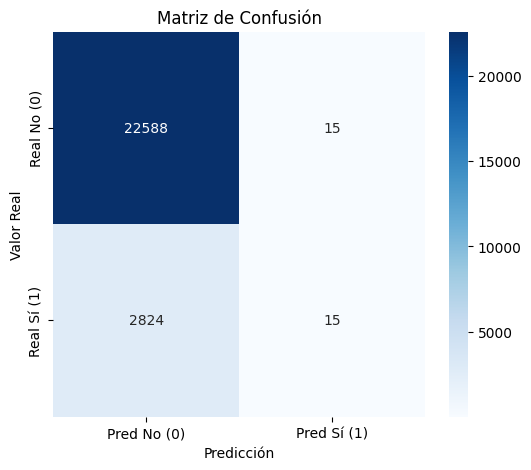

Verdaderos Negativos (TN): 22588
Falsos Positivos (FP): 15
Falsos Negativos (FN): 2824
Verdaderos Positivos (TP): 15


In [122]:
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred No (0)', 'Pred Sí (1)'], yticklabels=['Real No (0)', 'Real Sí (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()
print(f"Verdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

In [123]:
target_names = ['No Enfermedad (0)', 'Sí Enfermedad (1)']
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

No Enfermedad (0)       0.89      1.00      0.94     22603
Sí Enfermedad (1)       0.50      0.01      0.01      2839

         accuracy                           0.89     25442
        macro avg       0.69      0.50      0.48     25442
     weighted avg       0.85      0.89      0.84     25442



#####Ajuste para optimizar los resultados

Como el modelo no realizó una buena predicción de los casos "Si", ajustamos las probablidades de prevalencia. Como la proporción de readmitidos es baja y nuestro principal objetivo es lograr anticipar el mayor volumen de readmisiones generamos los siguientes ajustes:

In [124]:
# Prevalencia (baseline)
prev = y_test.mean()
print(f"Prevalencia de positivos en test: {prev:.3f}")

Prevalencia de positivos en test: 0.112


In [125]:
# Obtener y_proba del mejor modelo disponible
# Usar las probabilidades del modelo ya entrenado (model_pipeline)
if hasattr(RF_pipeline, "predict_proba"):
    y_proba = RF_pipeline.predict_proba(X_test)[:, 1]
else:
    raise AttributeError("El modelo no tiene predict_proba. Usa Random Forest o Regresión Logística.")

In [126]:
# Precision–Recall curve y selección de umbral
from sklearn.metrics import precision_recall_curve
import numpy as np

prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1s = 2*prec*rec/(prec+rec+1e-12)

In [127]:
# Umbral que maximiza F1
ix_f1 = np.nanargmax(f1s)
best_thr_f1 = thr[ix_f1] if ix_f1 < len(thr) else 0.5
print(f"Mejor umbral por F1: {best_thr_f1:.3f} | F1={f1s[ix_f1]:.3f} | Prec={prec[ix_f1]:.3f} | Rec={rec[ix_f1]:.3f}")

Mejor umbral por F1: 0.115 | F1=0.236 | Prec=0.149 | Rec=0.571


In [128]:
# Umbral con Recall mínimo deseado (ajustá target_recall según objetivo)
target_recall = 0.60
candidates = [(P,R,t) for P,R,t in zip(prec, rec, np.r_[thr, thr[-1]]) if R >= target_recall]
if candidates:
    best_prec, best_rec, best_thr_rec = max(candidates, key=lambda x: x[0])
    print(f"Umbral con Recall≥{target_recall:.2f}: thr={best_thr_rec:.3f} | Prec={best_prec:.3f} | Rec={best_rec:.3f}")
else:
    best_thr_rec = None
    print(f"No se encontró umbral con Recall≥{target_recall:.2f}.")

Umbral con Recall≥0.60: thr=0.105 | Prec=0.144 | Rec=0.623



--- Matriz de Confusión (umbral ajustado) ---


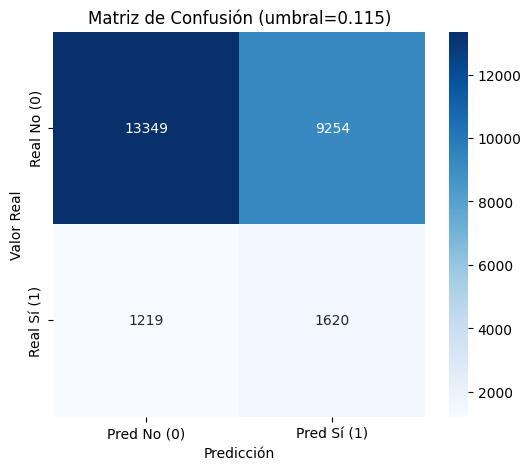

In [129]:
# Usar el mejor umbral encontrado (ejemplo: best_thr_f1)
thr_use = best_thr_f1 if 'best_thr_f1' in globals() else 0.5
y_pred_thr = (y_proba >= thr_use).astype(int)

print("\n--- Matriz de Confusión (umbral ajustado) ---")
cm = confusion_matrix(y_test, y_pred_thr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred No (0)', 'Pred Sí (1)'],
    yticklabels=['Real No (0)', 'Real Sí (1)']
)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title(f'Matriz de Confusión (umbral={thr_use:.3f})')
plt.show()

In [130]:
# Desglose de valores con umbral ajustado
print(f"Verdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

Verdaderos Negativos (TN): 13349
Falsos Positivos (FP): 9254
Falsos Negativos (FN): 1219
Verdaderos Positivos (TP): 1620


In [131]:
# Métricas con umbral ajustado
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision = precision_score(y_test, y_pred_thr)
recall = recall_score(y_test, y_pred_thr)
f1 = f1_score(y_test, y_pred_thr)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"\n--- Métricas Finales (umbral={thr_use:.3f}) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")


--- Métricas Finales (umbral=0.115) ---
Precision: 0.1490
Recall: 0.5706
F1-Score: 0.2363
AUC-ROC: 0.6095


In [132]:
# Reporte detallado con umbral ajustado
target_names = ['No Readmisión (0)', 'Sí Readmisión (1)']
print(f"\n--- Reporte de Clasificación (umbral ajustado) ---")
print(classification_report(y_test, y_pred_thr, target_names=target_names))


--- Reporte de Clasificación (umbral ajustado) ---
                   precision    recall  f1-score   support

No Readmisión (0)       0.92      0.59      0.72     22603
Sí Readmisión (1)       0.15      0.57      0.24      2839

         accuracy                           0.59     25442
        macro avg       0.53      0.58      0.48     25442
     weighted avg       0.83      0.59      0.66     25442



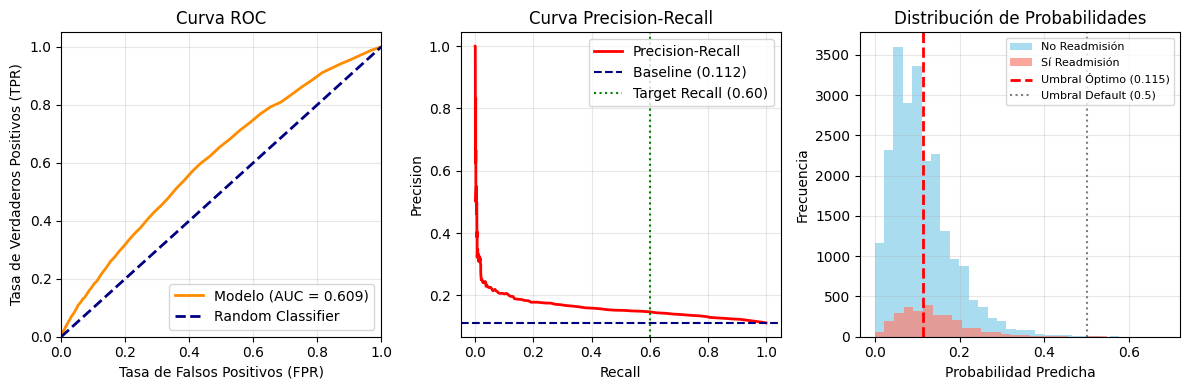

In [133]:
# Curvas ROC y Precision-Recall
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(12, 4))

# Subplot 1: Curva ROC
plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Modelo (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: Curva Precision-Recall
plt.subplot(1, 3, 2)
plt.plot(rec, prec, color='red', lw=2, label='Precision-Recall')
plt.axhline(y=prev, color='navy', linestyle='--', label=f'Baseline ({prev:.3f})')
plt.axvline(x=target_recall, color='green', linestyle=':', label=f'Target Recall ({target_recall:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Distribución de probabilidades predichas
plt.subplot(1, 3, 3)
plt.hist(y_proba[y_test==0], bins=30, alpha=0.7, label='No Readmisión', color='skyblue')
plt.hist(y_proba[y_test==1], bins=30, alpha=0.7, label='Sí Readmisión', color='salmon')
plt.axvline(thr_use, color='red', linestyle='--', linewidth=2, label=f'Umbral Óptimo ({thr_use:.3f})')
plt.axvline(0.5, color='black', linestyle=':', alpha=0.5, label='Umbral Default (0.5)')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [134]:
# Análisis de diferentes umbrales
print("Análisis de Diferentes Umbrales")
umbrales_test = [0.1, 0.2, 0.3, 0.4, 0.5, thr_use, 0.6, 0.7, 0.8]
print(f"{'Umbral':<8} {'Precision':<10} {'Recall':<8} {'F1-Score':<8} {'TP':<4} {'FP':<4} {'FN':<4} {'TN':<4}")
print("-" * 60)

for umbral in umbrales_test:
    y_pred_temp = (y_proba >= umbral).astype(int)
    cm_temp = confusion_matrix(y_test, y_pred_temp)

    prec_temp = precision_score(y_test, y_pred_temp) if cm_temp[1,1] > 0 else 0
    rec_temp = recall_score(y_test, y_pred_temp) if cm_temp[1,1] > 0 else 0
    f1_temp = f1_score(y_test, y_pred_temp) if cm_temp[1,1] > 0 else 0

    tn, fp, fn, tp = cm_temp.ravel()

    marker = " *" if abs(umbral - thr_use) < 0.001 else ""
    print(f"{umbral:<8.3f} {prec_temp:<10.3f} {rec_temp:<8.3f} {f1_temp:<8.3f} {tp:<4} {fp:<4} {fn:<4} {tn:<4}{marker}")

print("* Umbral óptimo seleccionado")

print("\n" + "="*60)
print("Resumen Optimización Umbral:")
print(f"• Umbral óptimo (por F1): {thr_use:.3f}")
print(f"• F1-Score optimizado: {f1:.4f}")
print(f"• Recall alcanzado: {recall:.4f}")
print(f"• Precision: {precision:.4f}")
print(f"• AUC-ROC: {auc_roc:.4f}")
print(f"• Mejora en Recall vs umbral 0.5: {recall - recall_score(y_test, RF_pipeline.predict(X_test)):.3f}")
print("="*60)

Análisis de Diferentes Umbrales
Umbral   Precision  Recall   F1-Score TP   FP   FN   TN  
------------------------------------------------------------
0.100    0.142      0.654    0.234    1858 11194 981  11409
0.200    0.178      0.192    0.185    545  2518 2294 20085
0.300    0.226      0.050    0.081    141  484  2698 22119
0.400    0.309      0.015    0.029    43   96   2796 22507
0.500    0.500      0.005    0.010    15   15   2824 22588
0.115    0.149      0.571    0.236    1620 9254 1219 13349 *
0.600    0.833      0.002    0.004    5    1    2834 22602
0.700    0.000      0.000    0.000    0    0    2839 22603
0.800    0.000      0.000    0.000    0    0    2839 22603
* Umbral óptimo seleccionado

Resumen Optimización Umbral:
• Umbral óptimo (por F1): 0.115
• F1-Score optimizado: 0.2363
• Recall alcanzado: 0.5706
• Precision: 0.1490
• AUC-ROC: 0.6095
• Mejora en Recall vs umbral 0.5: 0.565


###XGBoost

In [135]:
# Calcular el peso para balancear las clases
pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight calculado: {pos_weight:.2f}")

Scale pos weight calculado: 7.96


In [136]:
# Pipeline XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        random_state=42,
        eval_metric='logloss',
        verbosity=0  # Silenciar output
    ))
])

In [137]:
# Entrenar el pipeline completo (preprocesamiento + modelo)
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_diagnoses',
                                                   'medicare', 'medicaid',
                                                   'had_emergency',
                                                   'had_inpatient_days',
                                                   'had_outpatient_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gende...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [138]:
# Predicciones en el conjunto de testeo
y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [139]:
# Accuracy inicial
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"--- XGBoost Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy_xgb:.4f}")

--- XGBoost Accuracy Score ---
Accuracy en el conjunto de prueba: 0.6412



--- Matriz de Confusión (umbral 0.5) ---


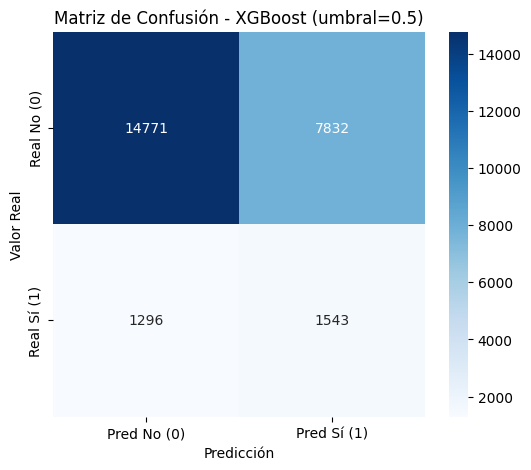

Verdaderos Negativos (TN): 14771
Falsos Positivos (FP): 7832
Falsos Negativos (FN): 1296
Verdaderos Positivos (TP): 1543


In [140]:
# Matriz de confusión inicial
print("\n--- Matriz de Confusión (umbral 0.5) ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Pred No (0)', 'Pred Sí (1)'],
           yticklabels=['Real No (0)', 'Real Sí (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - XGBoost (umbral=0.5)')
plt.show()

print(f"Verdaderos Negativos (TN): {cm_xgb[0,0]}")
print(f"Falsos Positivos (FP): {cm_xgb[0,1]}")
print(f"Falsos Negativos (FN): {cm_xgb[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_xgb[1,1]}")

In [141]:
# Reporte de clasificación inicial
target_names = ['No Readmisión (0)', 'Sí Readmisión (1)']
print("\n--- Reporte de Clasificación (umbral 0.5) ---")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))


--- Reporte de Clasificación (umbral 0.5) ---
                   precision    recall  f1-score   support

No Readmisión (0)       0.92      0.65      0.76     22603
Sí Readmisión (1)       0.16      0.54      0.25      2839

         accuracy                           0.64     25442
        macro avg       0.54      0.60      0.51     25442
     weighted avg       0.84      0.64      0.71     25442



#####Ajuste para optimizar los resultados

In [142]:
# Prevalencia (baseline)
prev_xgb = y_test.mean()
print(f"Prevalencia de positivos en test: {prev_xgb:.3f}")

Prevalencia de positivos en test: 0.112


In [143]:
# Precision–Recall curve y selección de umbral
from sklearn.metrics import precision_recall_curve

prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, y_pred_proba_xgb)
f1s_xgb = 2*prec_xgb*rec_xgb/(prec_xgb+rec_xgb+1e-12)

In [144]:
# Umbral que maximiza F1
ix_f1_xgb = np.nanargmax(f1s_xgb)
best_thr_f1_xgb = thr_xgb[ix_f1_xgb] if ix_f1_xgb < len(thr_xgb) else 0.5
print(f"Mejor umbral por F1: {best_thr_f1_xgb:.3f} | F1={f1s_xgb[ix_f1_xgb]:.3f} | Prec={prec_xgb[ix_f1_xgb]:.3f} | Rec={rec_xgb[ix_f1_xgb]:.3f}")

Mejor umbral por F1: 0.506 | F1=0.254 | Prec=0.167 | Rec=0.531


In [145]:
# Umbral con Recall mínimo deseado
target_recall = 0.60
candidates_xgb = [(P,R,t) for P,R,t in zip(prec_xgb, rec_xgb, np.r_[thr_xgb, thr_xgb[-1]]) if R >= target_recall]
if candidates_xgb:
    best_prec_xgb, best_rec_xgb, best_thr_rec_xgb = max(candidates_xgb, key=lambda x: x[0])
    print(f"Umbral con Recall≥{target_recall:.2f}: thr={best_thr_rec_xgb:.3f} | Prec={best_prec_xgb:.3f} | Rec={best_rec_xgb:.3f}")
else:
    best_thr_rec_xgb = None
    print(f"No se encontró umbral con Recall≥{target_recall:.2f}.")

Umbral con Recall≥0.60: thr=0.476 | Prec=0.160 | Rec=0.601



--- Matriz de Confusión (umbral ajustado) ---


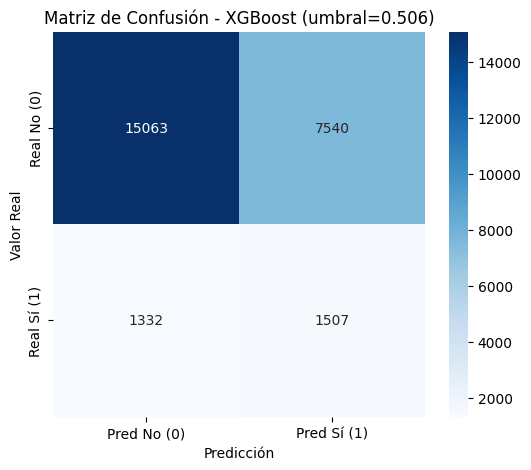

In [146]:
# Usar el mejor umbral encontrado
thr_use_xgb = best_thr_f1_xgb
y_pred_thr_xgb = (y_pred_proba_xgb >= thr_use_xgb).astype(int)

print("\n--- Matriz de Confusión (umbral ajustado) ---")
cm_adjusted_xgb = confusion_matrix(y_test, y_pred_thr_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_adjusted_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred No (0)', 'Pred Sí (1)'],
    yticklabels=['Real No (0)', 'Real Sí (1)']
)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title(f'Matriz de Confusión - XGBoost (umbral={thr_use_xgb:.3f})')
plt.show()

In [147]:
# Desglose de valores con umbral ajustado
print(f"Verdaderos Negativos (TN): {cm_adjusted_xgb[0,0]}")
print(f"Falsos Positivos (FP): {cm_adjusted_xgb[0,1]}")
print(f"Falsos Negativos (FN): {cm_adjusted_xgb[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_adjusted_xgb[1,1]}")

Verdaderos Negativos (TN): 15063
Falsos Positivos (FP): 7540
Falsos Negativos (FN): 1332
Verdaderos Positivos (TP): 1507


In [148]:
# Métricas con umbral ajustado
precision_xgb = precision_score(y_test, y_pred_thr_xgb)
recall_xgb = recall_score(y_test, y_pred_thr_xgb)
f1_xgb = f1_score(y_test, y_pred_thr_xgb)
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\n--- Métricas Finales XGBoost (umbral={thr_use_xgb:.3f}) ---")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"AUC-ROC: {auc_roc_xgb:.4f}")


--- Métricas Finales XGBoost (umbral=0.506) ---
Precision: 0.1666
Recall: 0.5308
F1-Score: 0.2536
AUC-ROC: 0.6351


In [149]:
# Reporte detallado con umbral ajustado
print(f"\n--- Reporte de Clasificación (umbral ajustado) ---")
print(classification_report(y_test, y_pred_thr_xgb, target_names=target_names))


--- Reporte de Clasificación (umbral ajustado) ---
                   precision    recall  f1-score   support

No Readmisión (0)       0.92      0.67      0.77     22603
Sí Readmisión (1)       0.17      0.53      0.25      2839

         accuracy                           0.65     25442
        macro avg       0.54      0.60      0.51     25442
     weighted avg       0.83      0.65      0.71     25442



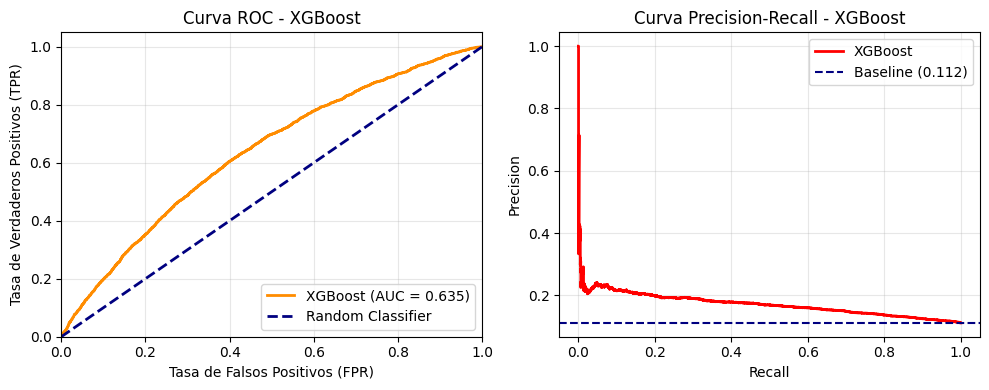

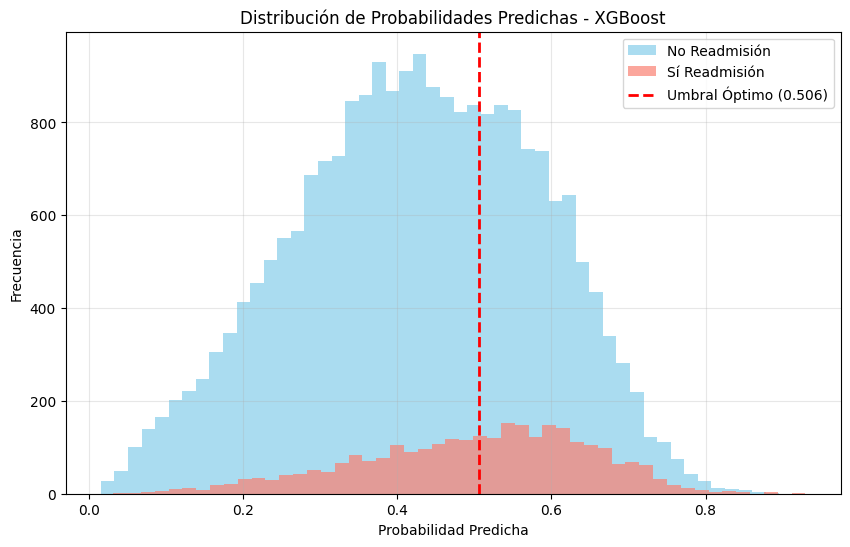

RESUMEN XGBoost:
• Umbral óptimo: 0.506
• F1-Score: 0.2536
• Recall: 0.5308
• Precision: 0.1666
• AUC-ROC: 0.6351


In [150]:
# Curva ROC
from sklearn.metrics import roc_curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 4))

# Subplot 1: Curva ROC
plt.subplot(1, 2, 1)
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
         label=f'XGBoost (AUC = {auc_roc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: Curva Precision-Recall
plt.subplot(1, 2, 2)
plt.plot(rec_xgb, prec_xgb, color='red', lw=2, label=f'XGBoost')
plt.axhline(y=prev_xgb, color='navy', linestyle='--', label=f'Baseline ({prev_xgb:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribución de probabilidades predichas
plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba_xgb[y_test==0], bins=50, alpha=0.7, label='No Readmisión', color='skyblue')
plt.hist(y_pred_proba_xgb[y_test==1], bins=50, alpha=0.7, label='Sí Readmisión', color='salmon')
plt.axvline(thr_use_xgb, color='red', linestyle='--', linewidth=2, label=f'Umbral Óptimo ({thr_use_xgb:.3f})')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades Predichas - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("="*60)
print("RESUMEN XGBoost:")
print(f"• Umbral óptimo: {thr_use_xgb:.3f}")
print(f"• F1-Score: {f1_xgb:.4f}")
print(f"• Recall: {recall_xgb:.4f}")
print(f"• Precision: {precision_xgb:.4f}")
print(f"• AUC-ROC: {auc_roc_xgb:.4f}")
print("="*60)


AJUSTE DE UMBRAL PARA OPTIMIZAR RECALL
Prevalencia de positivos en test: 0.112
Mejor umbral por F1: 0.506 | F1=0.254 | Prec=0.167 | Rec=0.531
Umbral con Recall≥0.60: thr=0.476 | Prec=0.160 | Rec=0.601

--- Matriz de Confusión (umbral ajustado) ---


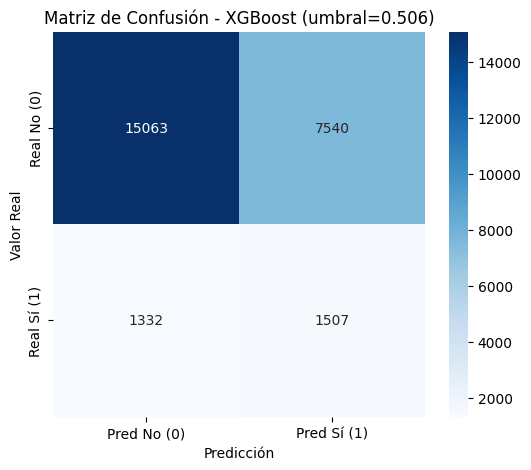

Verdaderos Negativos (TN): 15063
Falsos Positivos (FP): 7540
Falsos Negativos (FN): 1332
Verdaderos Positivos (TP): 1507

--- Métricas Finales XGBoost (umbral=0.506) ---
Precision: 0.1666
Recall: 0.5308
F1-Score: 0.2536
AUC-ROC: 0.6351

--- Reporte de Clasificación (umbral ajustado) ---
                   precision    recall  f1-score   support

No Readmisión (0)       0.92      0.67      0.77     22603
Sí Readmisión (1)       0.17      0.53      0.25      2839

         accuracy                           0.65     25442
        macro avg       0.54      0.60      0.51     25442
     weighted avg       0.83      0.65      0.71     25442



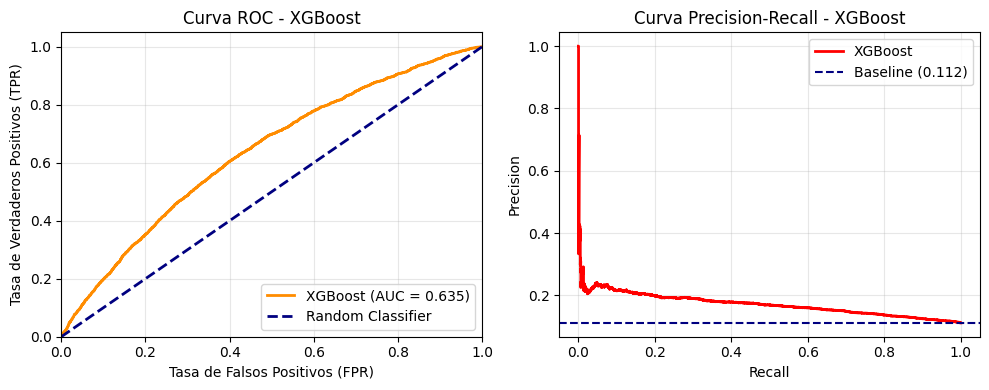

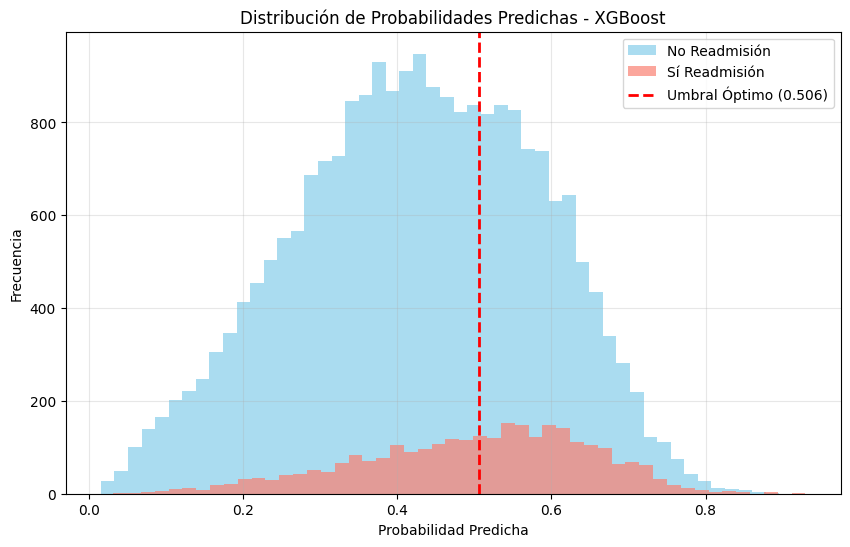

RESUMEN XGBoost:
• Umbral óptimo: 0.506
• F1-Score: 0.2536
• Recall: 0.5308
• Precision: 0.1666
• AUC-ROC: 0.6351


In [151]:
# === AJUSTE DE UMBRAL ===
print("\n" + "="*50)
print("AJUSTE DE UMBRAL PARA OPTIMIZAR RECALL")
print("="*50)

# Prevalencia (baseline)
prev_xgb = y_test.mean()
print(f"Prevalencia de positivos en test: {prev_xgb:.3f}")

# Precision–Recall curve y selección de umbral
from sklearn.metrics import precision_recall_curve

prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, y_pred_proba_xgb)
f1s_xgb = 2*prec_xgb*rec_xgb/(prec_xgb+rec_xgb+1e-12)

# Umbral que maximiza F1
ix_f1_xgb = np.nanargmax(f1s_xgb)
best_thr_f1_xgb = thr_xgb[ix_f1_xgb] if ix_f1_xgb < len(thr_xgb) else 0.5
print(f"Mejor umbral por F1: {best_thr_f1_xgb:.3f} | F1={f1s_xgb[ix_f1_xgb]:.3f} | Prec={prec_xgb[ix_f1_xgb]:.3f} | Rec={rec_xgb[ix_f1_xgb]:.3f}")

# Umbral con Recall mínimo deseado
target_recall = 0.60
candidates_xgb = [(P,R,t) for P,R,t in zip(prec_xgb, rec_xgb, np.r_[thr_xgb, thr_xgb[-1]]) if R >= target_recall]
if candidates_xgb:
    best_prec_xgb, best_rec_xgb, best_thr_rec_xgb = max(candidates_xgb, key=lambda x: x[0])
    print(f"Umbral con Recall≥{target_recall:.2f}: thr={best_thr_rec_xgb:.3f} | Prec={best_prec_xgb:.3f} | Rec={best_rec_xgb:.3f}")
else:
    best_thr_rec_xgb = None
    print(f"No se encontró umbral con Recall≥{target_recall:.2f}.")

# Usar el mejor umbral encontrado
thr_use_xgb = best_thr_f1_xgb
y_pred_thr_xgb = (y_pred_proba_xgb >= thr_use_xgb).astype(int)

print("\n--- Matriz de Confusión (umbral ajustado) ---")
cm_adjusted_xgb = confusion_matrix(y_test, y_pred_thr_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_adjusted_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred No (0)', 'Pred Sí (1)'],
    yticklabels=['Real No (0)', 'Real Sí (1)']
)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title(f'Matriz de Confusión - XGBoost (umbral={thr_use_xgb:.3f})')
plt.show()

# Desglose de valores con umbral ajustado
print(f"Verdaderos Negativos (TN): {cm_adjusted_xgb[0,0]}")
print(f"Falsos Positivos (FP): {cm_adjusted_xgb[0,1]}")
print(f"Falsos Negativos (FN): {cm_adjusted_xgb[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_adjusted_xgb[1,1]}")

# Métricas con umbral ajustado
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision_xgb = precision_score(y_test, y_pred_thr_xgb)
recall_xgb = recall_score(y_test, y_pred_thr_xgb)
f1_xgb = f1_score(y_test, y_pred_thr_xgb)
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\n--- Métricas Finales XGBoost (umbral={thr_use_xgb:.3f}) ---")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"AUC-ROC: {auc_roc_xgb:.4f}")

# Reporte detallado con umbral ajustado
print(f"\n--- Reporte de Clasificación (umbral ajustado) ---")
print(classification_report(y_test, y_pred_thr_xgb, target_names=target_names))

# === VISUALIZACIONES ADICIONALES ===

# Curva ROC
from sklearn.metrics import roc_curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 4))

# Subplot 1: Curva ROC
plt.subplot(1, 2, 1)
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
         label=f'XGBoost (AUC = {auc_roc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: Curva Precision-Recall
plt.subplot(1, 2, 2)
plt.plot(rec_xgb, prec_xgb, color='red', lw=2, label=f'XGBoost')
plt.axhline(y=prev_xgb, color='navy', linestyle='--', label=f'Baseline ({prev_xgb:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribución de probabilidades predichas
plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba_xgb[y_test==0], bins=50, alpha=0.7, label='No Readmisión', color='skyblue')
plt.hist(y_pred_proba_xgb[y_test==1], bins=50, alpha=0.7, label='Sí Readmisión', color='salmon')
plt.axvline(thr_use_xgb, color='red', linestyle='--', linewidth=2, label=f'Umbral Óptimo ({thr_use_xgb:.3f})')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades Predichas - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("="*60)
print("RESUMEN XGBoost:")
print(f"• Umbral óptimo: {thr_use_xgb:.3f}")
print(f"• F1-Score: {f1_xgb:.4f}")
print(f"• Recall: {recall_xgb:.4f}")
print(f"• Precision: {precision_xgb:.4f}")
print(f"• AUC-ROC: {auc_roc_xgb:.4f}")
print("="*60)

##Comparación Modelos

In [152]:
# Define metrics dictionaries for each model
rf_metrics = {
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'auc_roc': auc_roc,
    'threshold': thr_use,
    'y_pred': y_pred_thr,
    'y_proba': y_proba
}

xgb_metrics = {
    'precision': precision_xgb,
    'recall': recall_xgb,
    'f1': f1_xgb,
    'auc_roc': auc_roc_xgb,
    'threshold': thr_use_xgb,
    'y_pred': y_pred_thr_xgb,
    'y_proba': y_pred_proba_xgb
}


print(f"{'Métrica':<20} {'Random Forest':<15} {'XGBoost':<15} {'Diferencia':<15}")
print("-" * 70)

# Calcular diferencias
diff_precision = xgb_metrics['precision'] - rf_metrics['precision']
diff_recall = xgb_metrics['recall'] - rf_metrics['recall']
diff_f1 = xgb_metrics['f1'] - rf_metrics['f1']
diff_auc = xgb_metrics['auc_roc'] - rf_metrics['auc_roc']

print(f"{'Precision':<20} {rf_metrics['precision']:<15.4f} {xgb_metrics['precision']:<15.4f} {diff_precision:>+8.4f}")
print(f"{'Recall':<20} {rf_metrics['recall']:<15.4f} {xgb_metrics['recall']:<15.4f} {diff_recall:>+8.4f}")
print(f"{'F1-Score':<20} {rf_metrics['f1']:<15.4f} {xgb_metrics['f1']:<15.4f} {diff_f1:>+8.4f}")
print(f"{'AUC-ROC':<20} {rf_metrics['auc_roc']:<15.4f} {xgb_metrics['auc_roc']:<15.4f} {diff_auc:>+8.4f}")
print(f"{'Umbral Óptimo':<20} {rf_metrics['threshold']:<15.3f} {xgb_metrics['threshold']:<15.3f}")

Métrica              Random Forest   XGBoost         Diferencia     
----------------------------------------------------------------------
Precision            0.1490          0.1666           +0.0176
Recall               0.5706          0.5308           -0.0398
F1-Score             0.2363          0.2536           +0.0173
AUC-ROC              0.6095          0.6351           +0.0256
Umbral Óptimo        0.115           0.506          


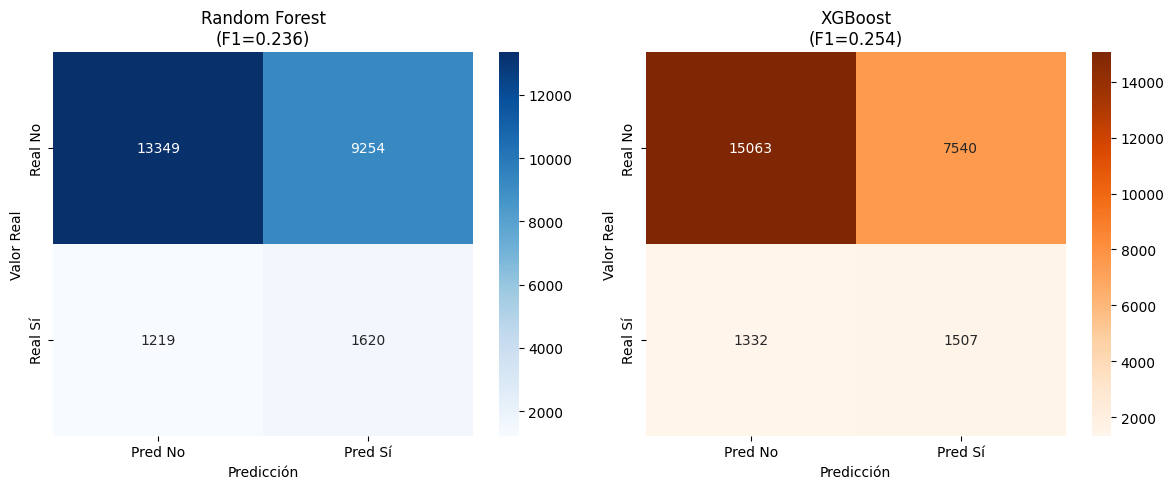

In [153]:
# Calcular matrices de confusión
cm_rf = confusion_matrix(y_test, rf_metrics['y_pred'])
cm_xgb = confusion_matrix(y_test, xgb_metrics['y_pred'])

# Visualización lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Pred No', 'Pred Sí'],
           yticklabels=['Real No', 'Real Sí'])
axes[0].set_title(f'Random Forest\n(F1={rf_metrics["f1"]:.3f})')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
           xticklabels=['Pred No', 'Pred Sí'],
           yticklabels=['Real No', 'Real Sí'])
axes[1].set_title(f'XGBoost\n(F1={xgb_metrics["f1"]:.3f})')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [154]:
# Desglose detallado
print(f"Random Forest - TN:{cm_rf[0,0]}, FP:{cm_rf[0,1]}, FN:{cm_rf[1,0]}, TP:{cm_rf[1,1]}")
print(f"XGBoost      - TN:{cm_xgb[0,0]}, FP:{cm_xgb[0,1]}, FN:{cm_xgb[1,0]}, TP:{cm_xgb[1,1]}")

Random Forest - TN:13349, FP:9254, FN:1219, TP:1620
XGBoost      - TN:15063, FP:7540, FN:1332, TP:1507


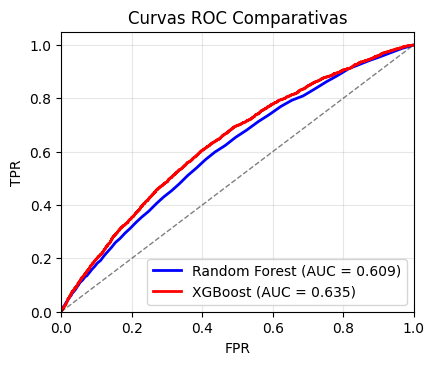

In [155]:
# Calcular curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_metrics['y_proba'])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_metrics['y_proba'])

plt.figure(figsize=(10, 8))

# Curva ROC comparativa
plt.subplot(2, 2, 1)
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2,
         label=f'Random Forest (AUC = {rf_metrics["auc_roc"]:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2,
         label=f'XGBoost (AUC = {xgb_metrics["auc_roc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC Comparativas')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

In [156]:
    print("SISTEMA DE PUNTUACIÓN PARA SELECCIÓN DEL MEJOR MODELO")

    # Sistema de puntuación para elegir el modelo, priorizaremos mas Recall y F1. En problemas de tipo salud es lo mas recomendado
    pesos = {
        'recall': 0.35,      # Más importante: no perder pacientes reales
        'f1': 0.30,          # Balance general
        'auc_roc': 0.20,     # Capacidad discriminativa
        'precision': 0.15    # Menos crítico: está bien tener algunas falsas alarmas
    }

    print("Pesos utilizados (contexto médico):")
    for metrica, peso in pesos.items():
        print(f"  {metrica.capitalize()}: {peso:.2f}")

    # Calcular puntuaciones ponderadas
    score_rf = (rf_metrics['recall'] * pesos['recall'] +
                rf_metrics['f1'] * pesos['f1'] +
                rf_metrics['auc_roc'] * pesos['auc_roc'] +
                rf_metrics['precision'] * pesos['precision'])

    score_xgb = (xgb_metrics['recall'] * pesos['recall'] +
                 xgb_metrics['f1'] * pesos['f1'] +
                 xgb_metrics['auc_roc'] * pesos['auc_roc'] +
                 xgb_metrics['precision'] * pesos['precision'])

    print(f"\nPuntuaciones Finales:")
    print(f"Random Forest: {score_rf:.4f}")
    print(f"XGBoost:       {score_xgb:.4f}")
    print(f"Diferencia:    {abs(score_xgb - score_rf):.4f}")

    #Selección
    print("Selección de Modelo:")
    print("")

    if score_xgb > score_rf:
        best_model_name = "XGBoost"
        best_metrics = xgb_metrics
        margin = score_xgb - score_rf
    else:
        best_model_name = "Random Forest"
        best_metrics = rf_metrics
        margin = score_rf - score_xgb

    print(f"   GANADOR: {best_model_name}")
    print("")
    print(f"   Margen de victoria: {margin:.4f}")
    print(f"   Métricas del modelo ganador:")
    print(f"   • Precision: {best_metrics['precision']:.4f}")
    print(f"   • Recall: {best_metrics['recall']:.4f}")
    print(f"   • F1-Score: {best_metrics['f1']:.4f}")
    print(f"   • AUC-ROC: {best_metrics['auc_roc']:.4f}")
    print(f"   • Umbral óptimo: {best_metrics['threshold']:.3f}")

SISTEMA DE PUNTUACIÓN PARA SELECCIÓN DEL MEJOR MODELO
Pesos utilizados (contexto médico):
  Recall: 0.35
  F1: 0.30
  Auc_roc: 0.20
  Precision: 0.15

Puntuaciones Finales:
Random Forest: 0.4148
XGBoost:       0.4139
Diferencia:    0.0010
Selección de Modelo:

   GANADOR: Random Forest

   Margen de victoria: 0.0010
   Métricas del modelo ganador:
   • Precision: 0.1490
   • Recall: 0.5706
   • F1-Score: 0.2363
   • AUC-ROC: 0.6095
   • Umbral óptimo: 0.115


##Conclusiones

Ambos modelos presentaron una performans similar, con dificultad para tener un alto nivel de acuracy, por las caracteristicas del modelo se priorizó la detección de positivos y mediante el balanceo de los modelos se mejoraron los resultados.

El modelo elegido fue **Random Forest**, con muy bajo margen en el sistema de puntuación desarrollado.

Una característica del modelo fue que tuvo baja presición, motorizada por una alta tasa de falsos positivos. (0.149)

El recall, caracteristica que se priorizó tuvo mejor valoración (0.5706)


